# [LAB 08] 3. 추론통계
## #연습문제

In [1]:
%%capture cap
%run "./08. PBT - EDAㅣ1-EDA 시작하기(연습문제).ipynb"

In [2]:
print("목표변수 :", target)
print("연속형(종속변수 포함):", continuous_cols)
print('독립변수(명목형):', nominal_cols)
print('독립변수(연속형):', feature_continuous)

display(df.head())
display(desc.head())
display(cat_desc.head())

목표변수 : charges
연속형(종속변수 포함): ['age', 'bmi', 'children', 'charges']
독립변수(명목형): ['sex', 'smoker', 'region']
독립변수(연속형): ['age', 'bmi', 'children']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log1p


,Unnamed: 0,sex,smoker,region
0,count,1337,1337,1337
1,unique,2,2,4
2,top,male,no,southeast
3,freq,675,1063,364


In [3]:
from pandas import DataFrame, cut

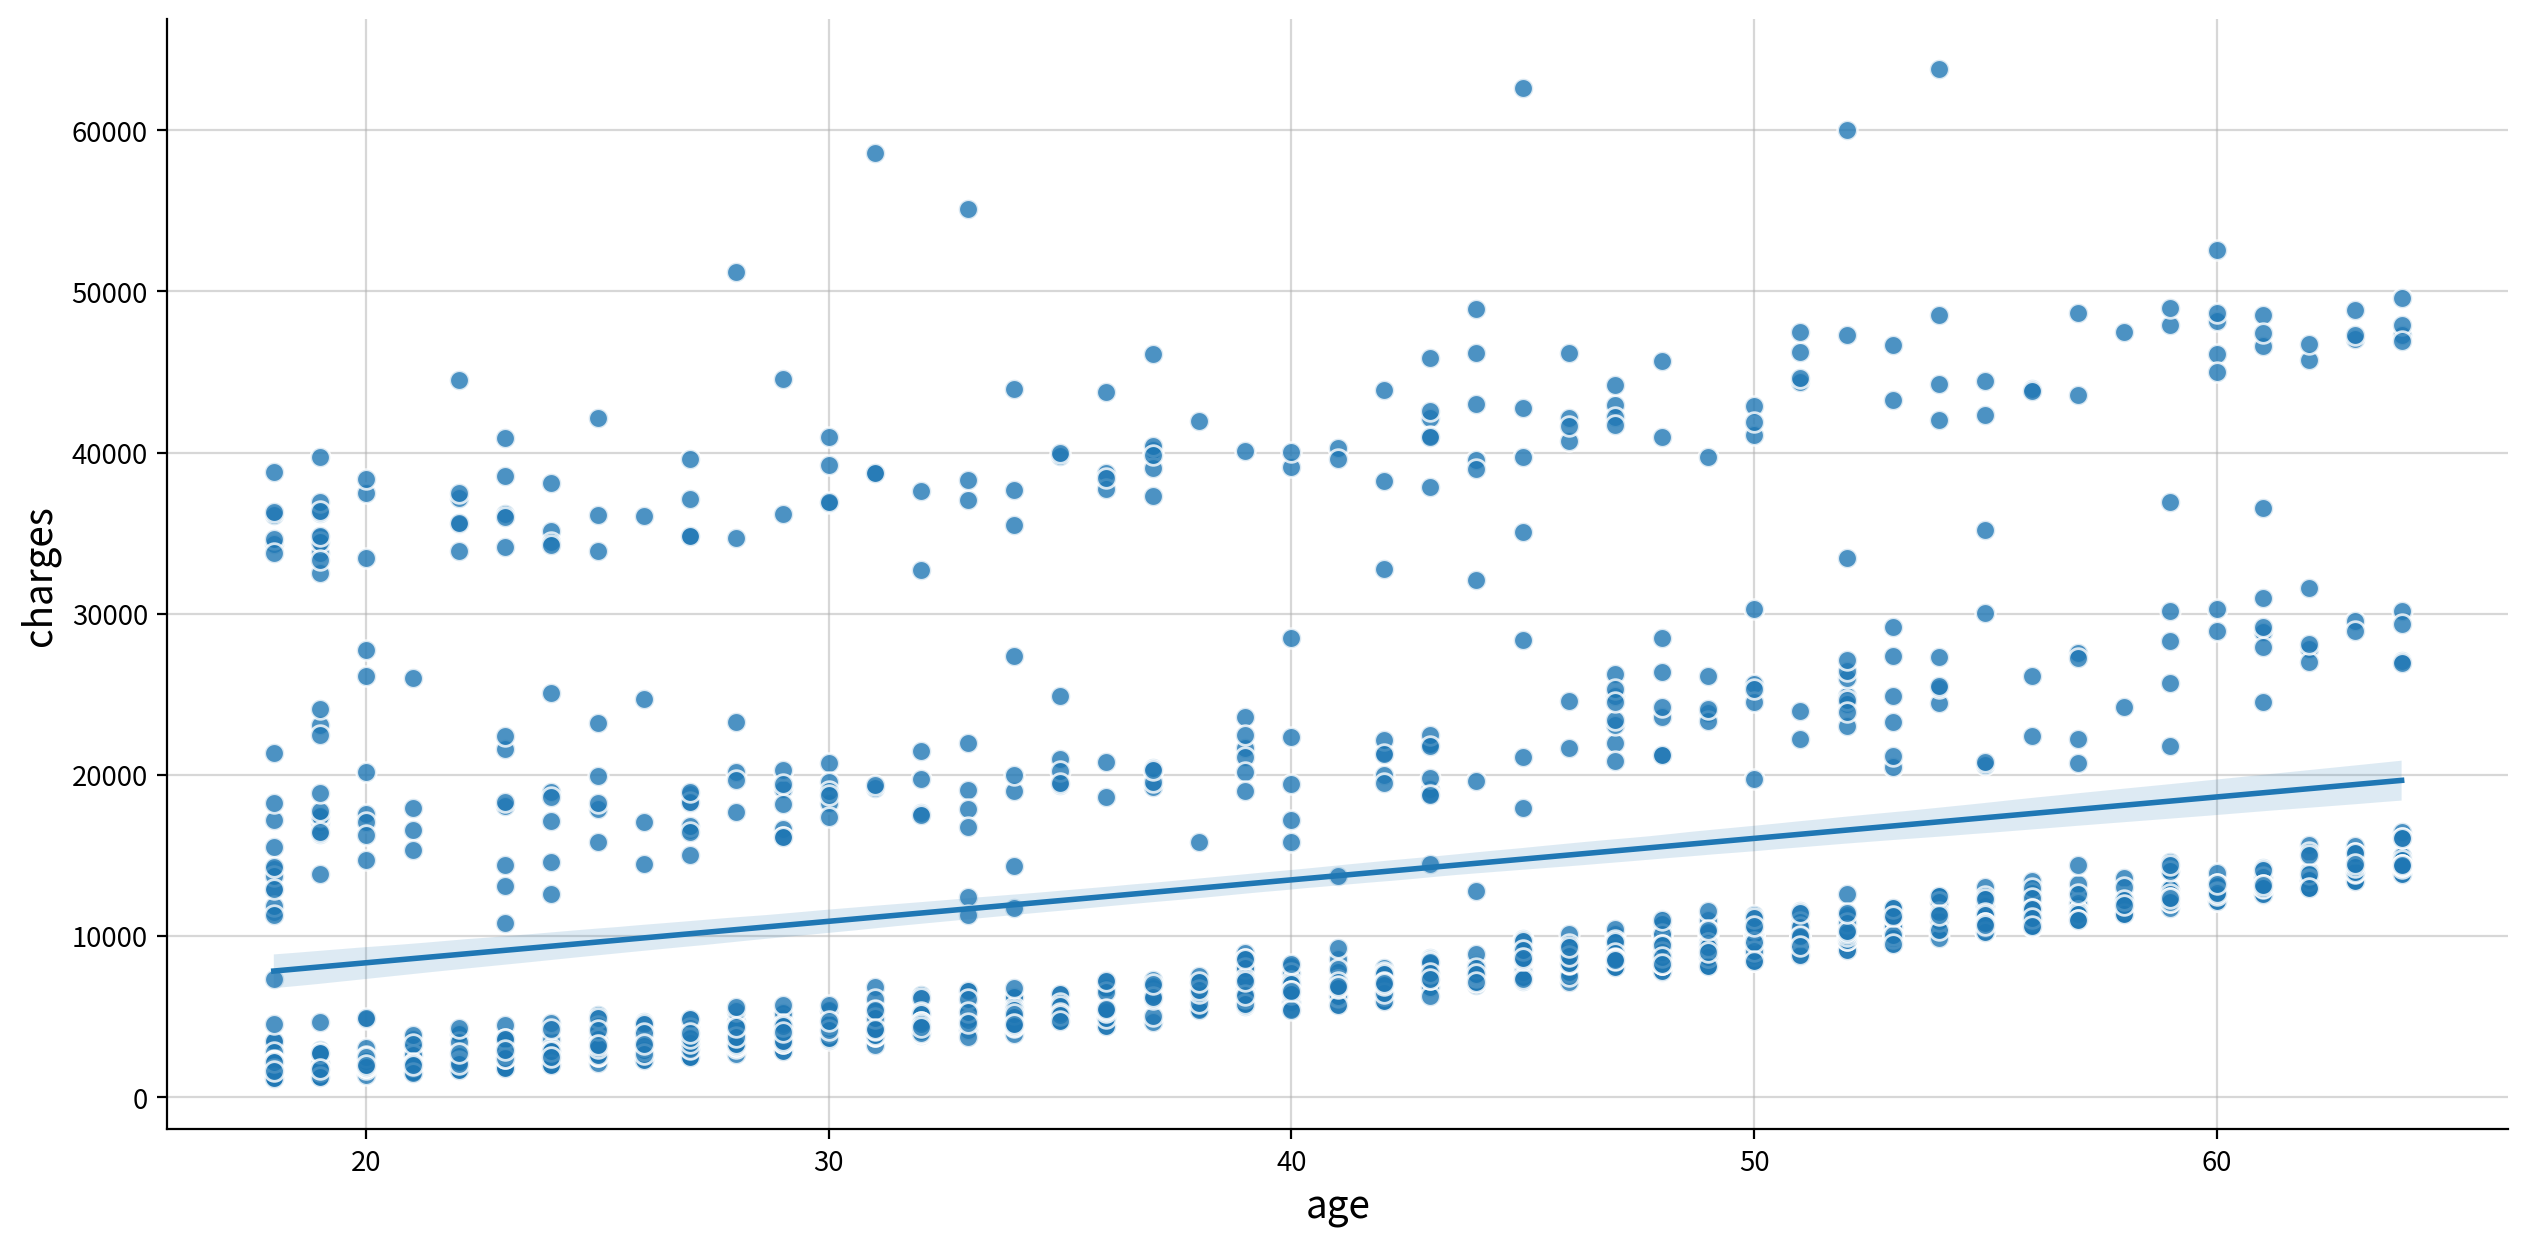


독립변수 : age


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
age,charges,Spearman,0.533,0.000,Moderate,True,False,False,True,True,True


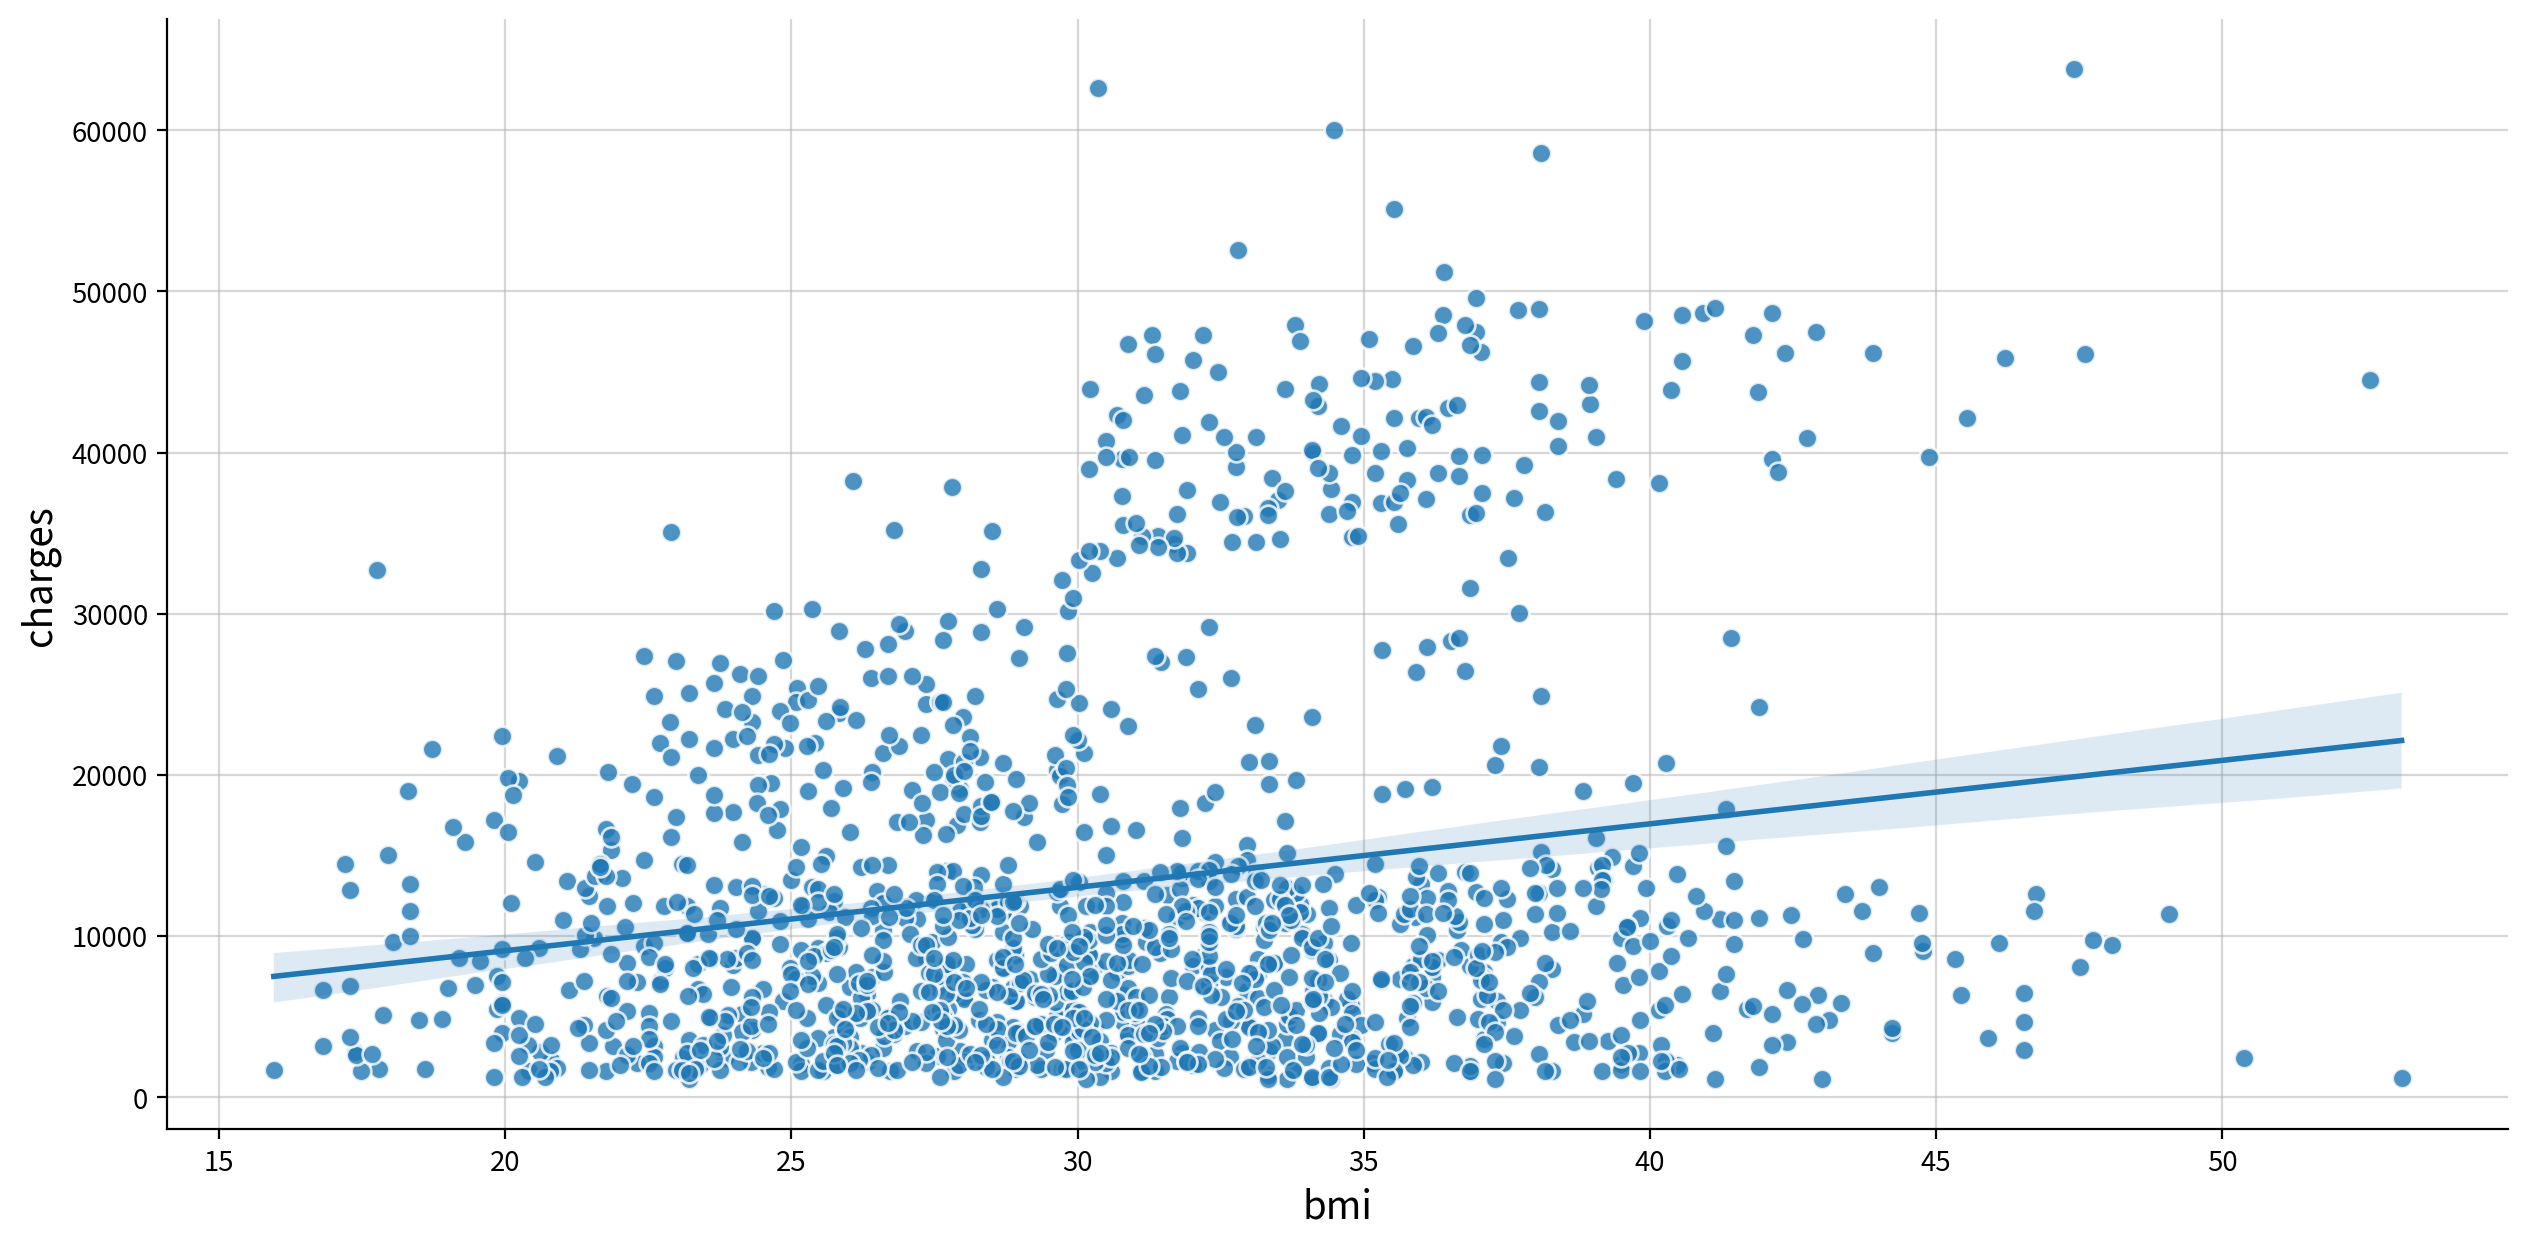


독립변수 : bmi


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bmi,charges,Spearman,0.120,0.000,Weak,True,False,False,True,True,True


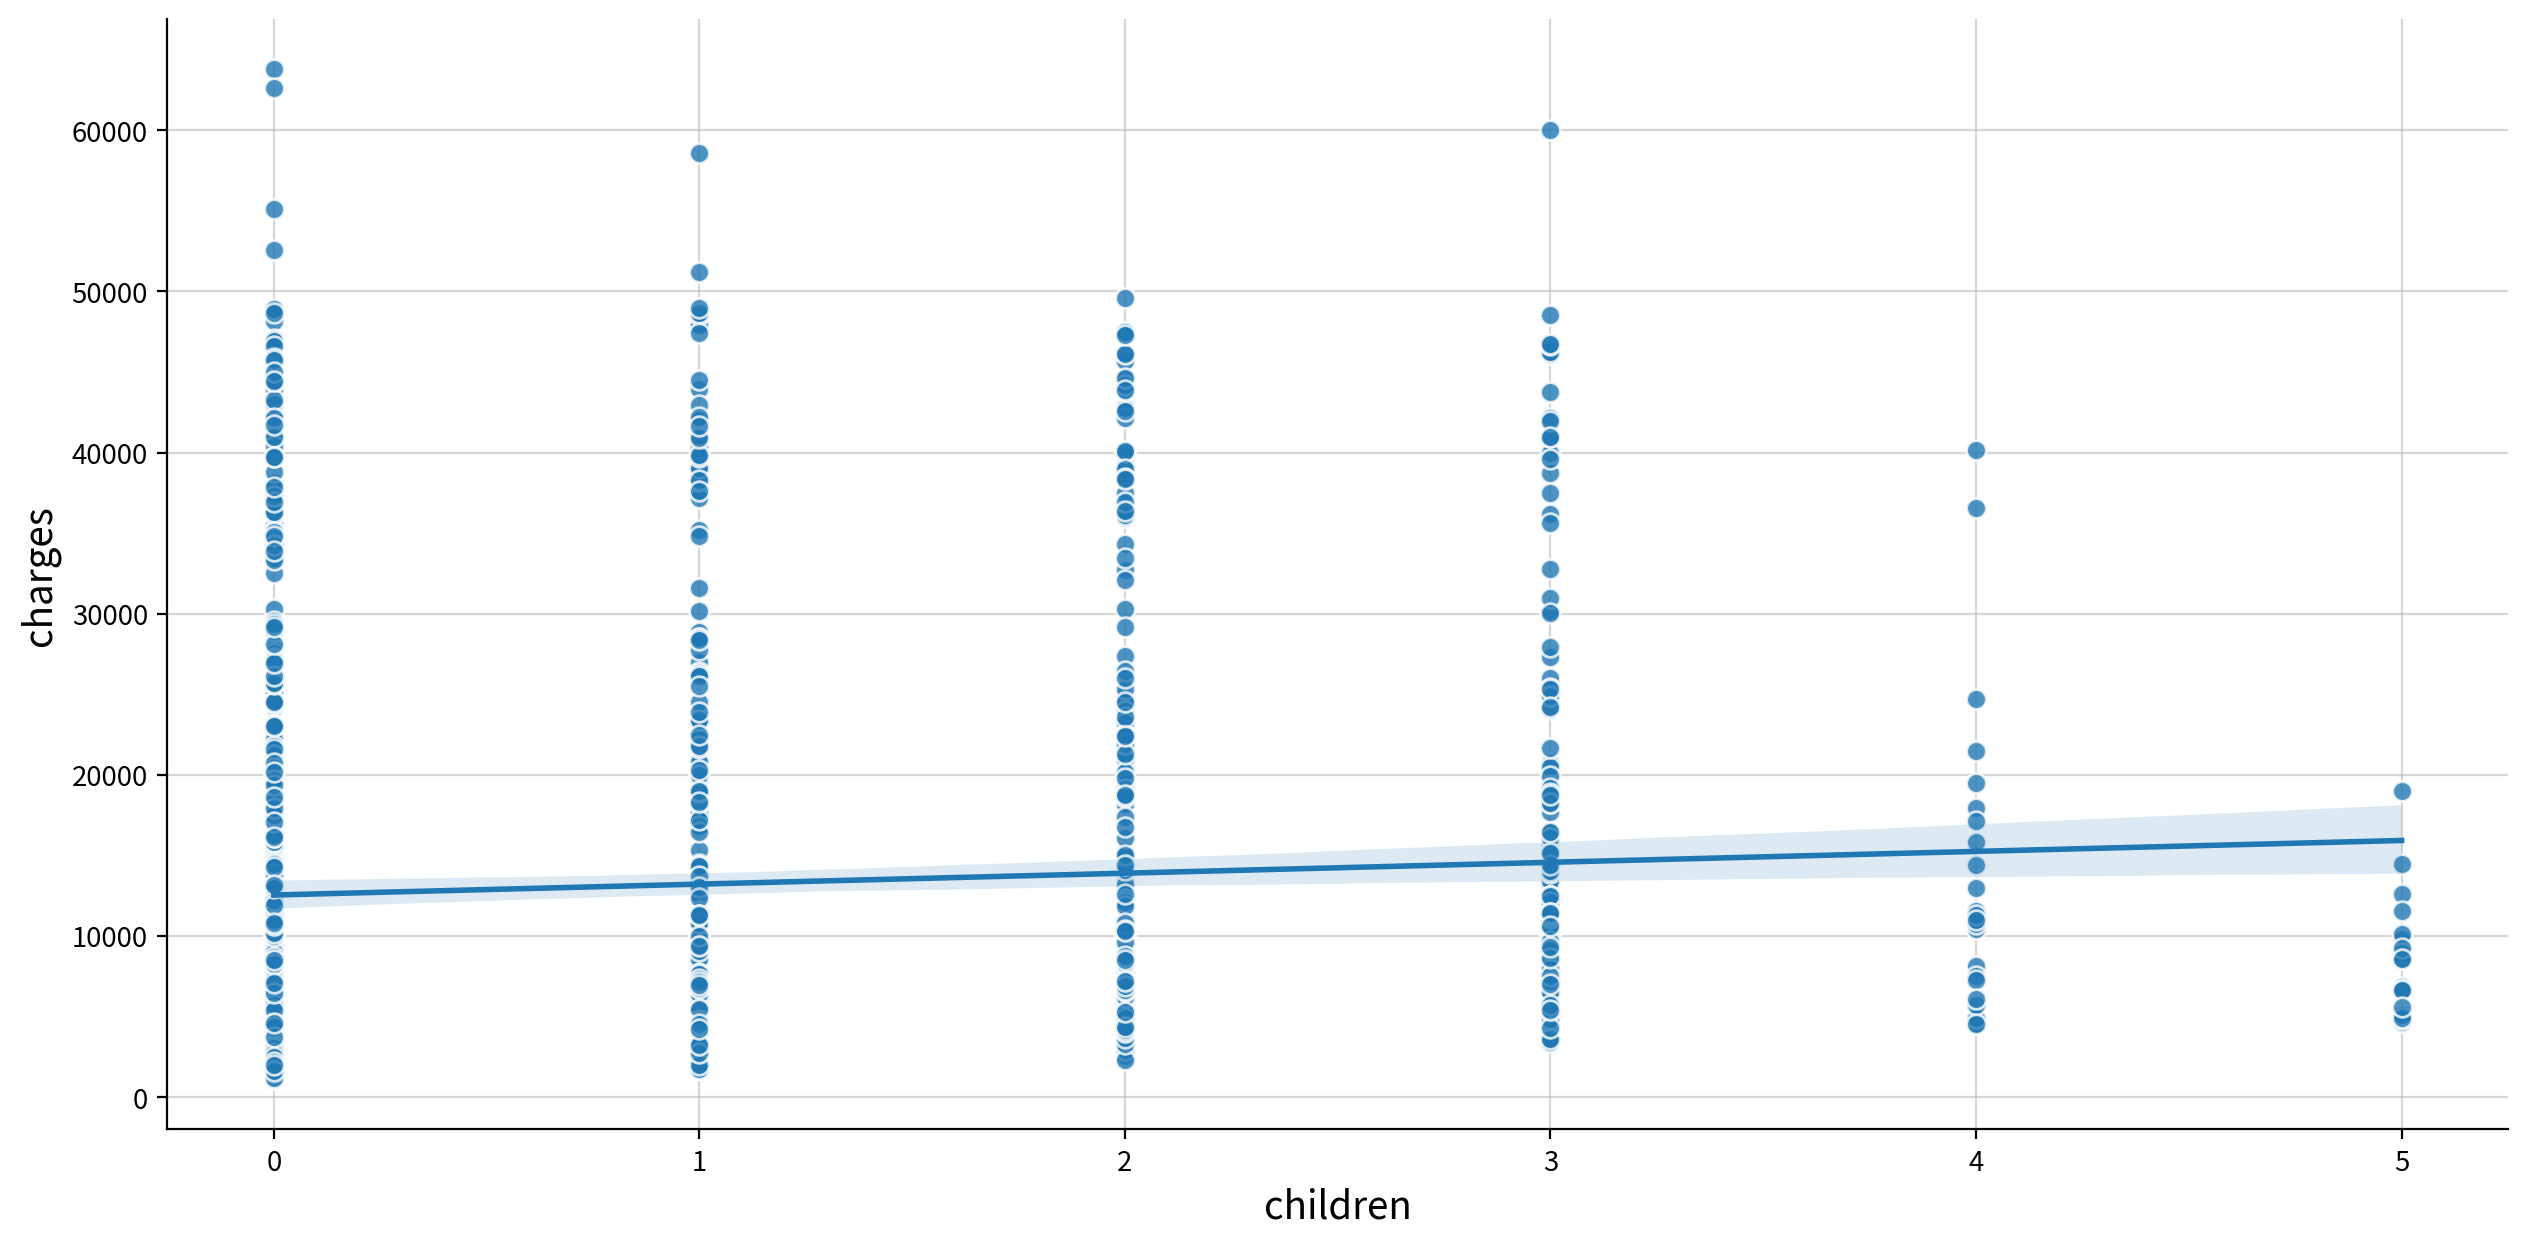


독립변수 : children


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
children,charges,Spearman,0.132,0.000,Weak,True,False,False,False,False,True


In [4]:
for f in feature_continuous:
    result = my_stats.correlation(df, x=f, y=target)
    print(f'\n독립변수 : {f}')
    display(result)

- 인사이트
- 검정선택 : 모든 쌍에서 정규성 위배(normality=False) → Spearman P 자동 적용(비모수). 3개 변수 모두 p<0.001로 유의
- 채택기준 : p<0.05 & |r|>=0.3 → 독립변수 후보로 채택

|변수|coef|방향|강도|채택|
|-|-|-|-|-|
|age|0.533|정(+)|강함|채택|
|bmi|0.120|정(+)|약함|x|
|children|0.132|정(+)|약함|x|

- 핵심 : age가 |r|=0.533로 charges와 가장 강한 양(+)의 상관 → 해당 변수가 보험료 설명력의 핵심 후보
- bmi와 children 두개 변수는 |r|<0.3(약함)이라 후보에서 제외
- 다만, 상관과 인과는 같지 않으므로 원인으로 단정짓지 않음

In [5]:
my_stats.multi_correlation(df, columns=feature_continuous, plot=False)

method  coef  p-value strength  significant  normality_x  \
x   y                                                                      
age bmi       Spearman 0.108    0.000     Weak         True        False   
    children  Spearman 0.056    0.041     Weak         True        False   
bmi children  Spearman 0.016    0.568     Weak        False        False   

              normality_y  linearity  influential_outlier  high_skew  
x   y                                                                 
age bmi             False       True                False      False  
    children        False      False                False      False  
bmi children        False       True                False      False

,age,bmi,children
age,1.000,0.108,0.056
bmi,0.108,1.000,0.016
children,0.056,0.016,1.000


- 인사이트
- 연속형 변수간 다중공선성 신호를 감지했을 때 강한 상관 변수쌍을 가진 값은 없음(|r|>=0.7) - 다중 공선성 위험은 없음

### T검정
#### 이진 명목형 변수 ↔ 연속

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

비흡연(no) vs. 흡연(yes): Mann-Whitney-Wilcoxon test two-sided, P_val:5.747e-130 U_stat=7.403e+03


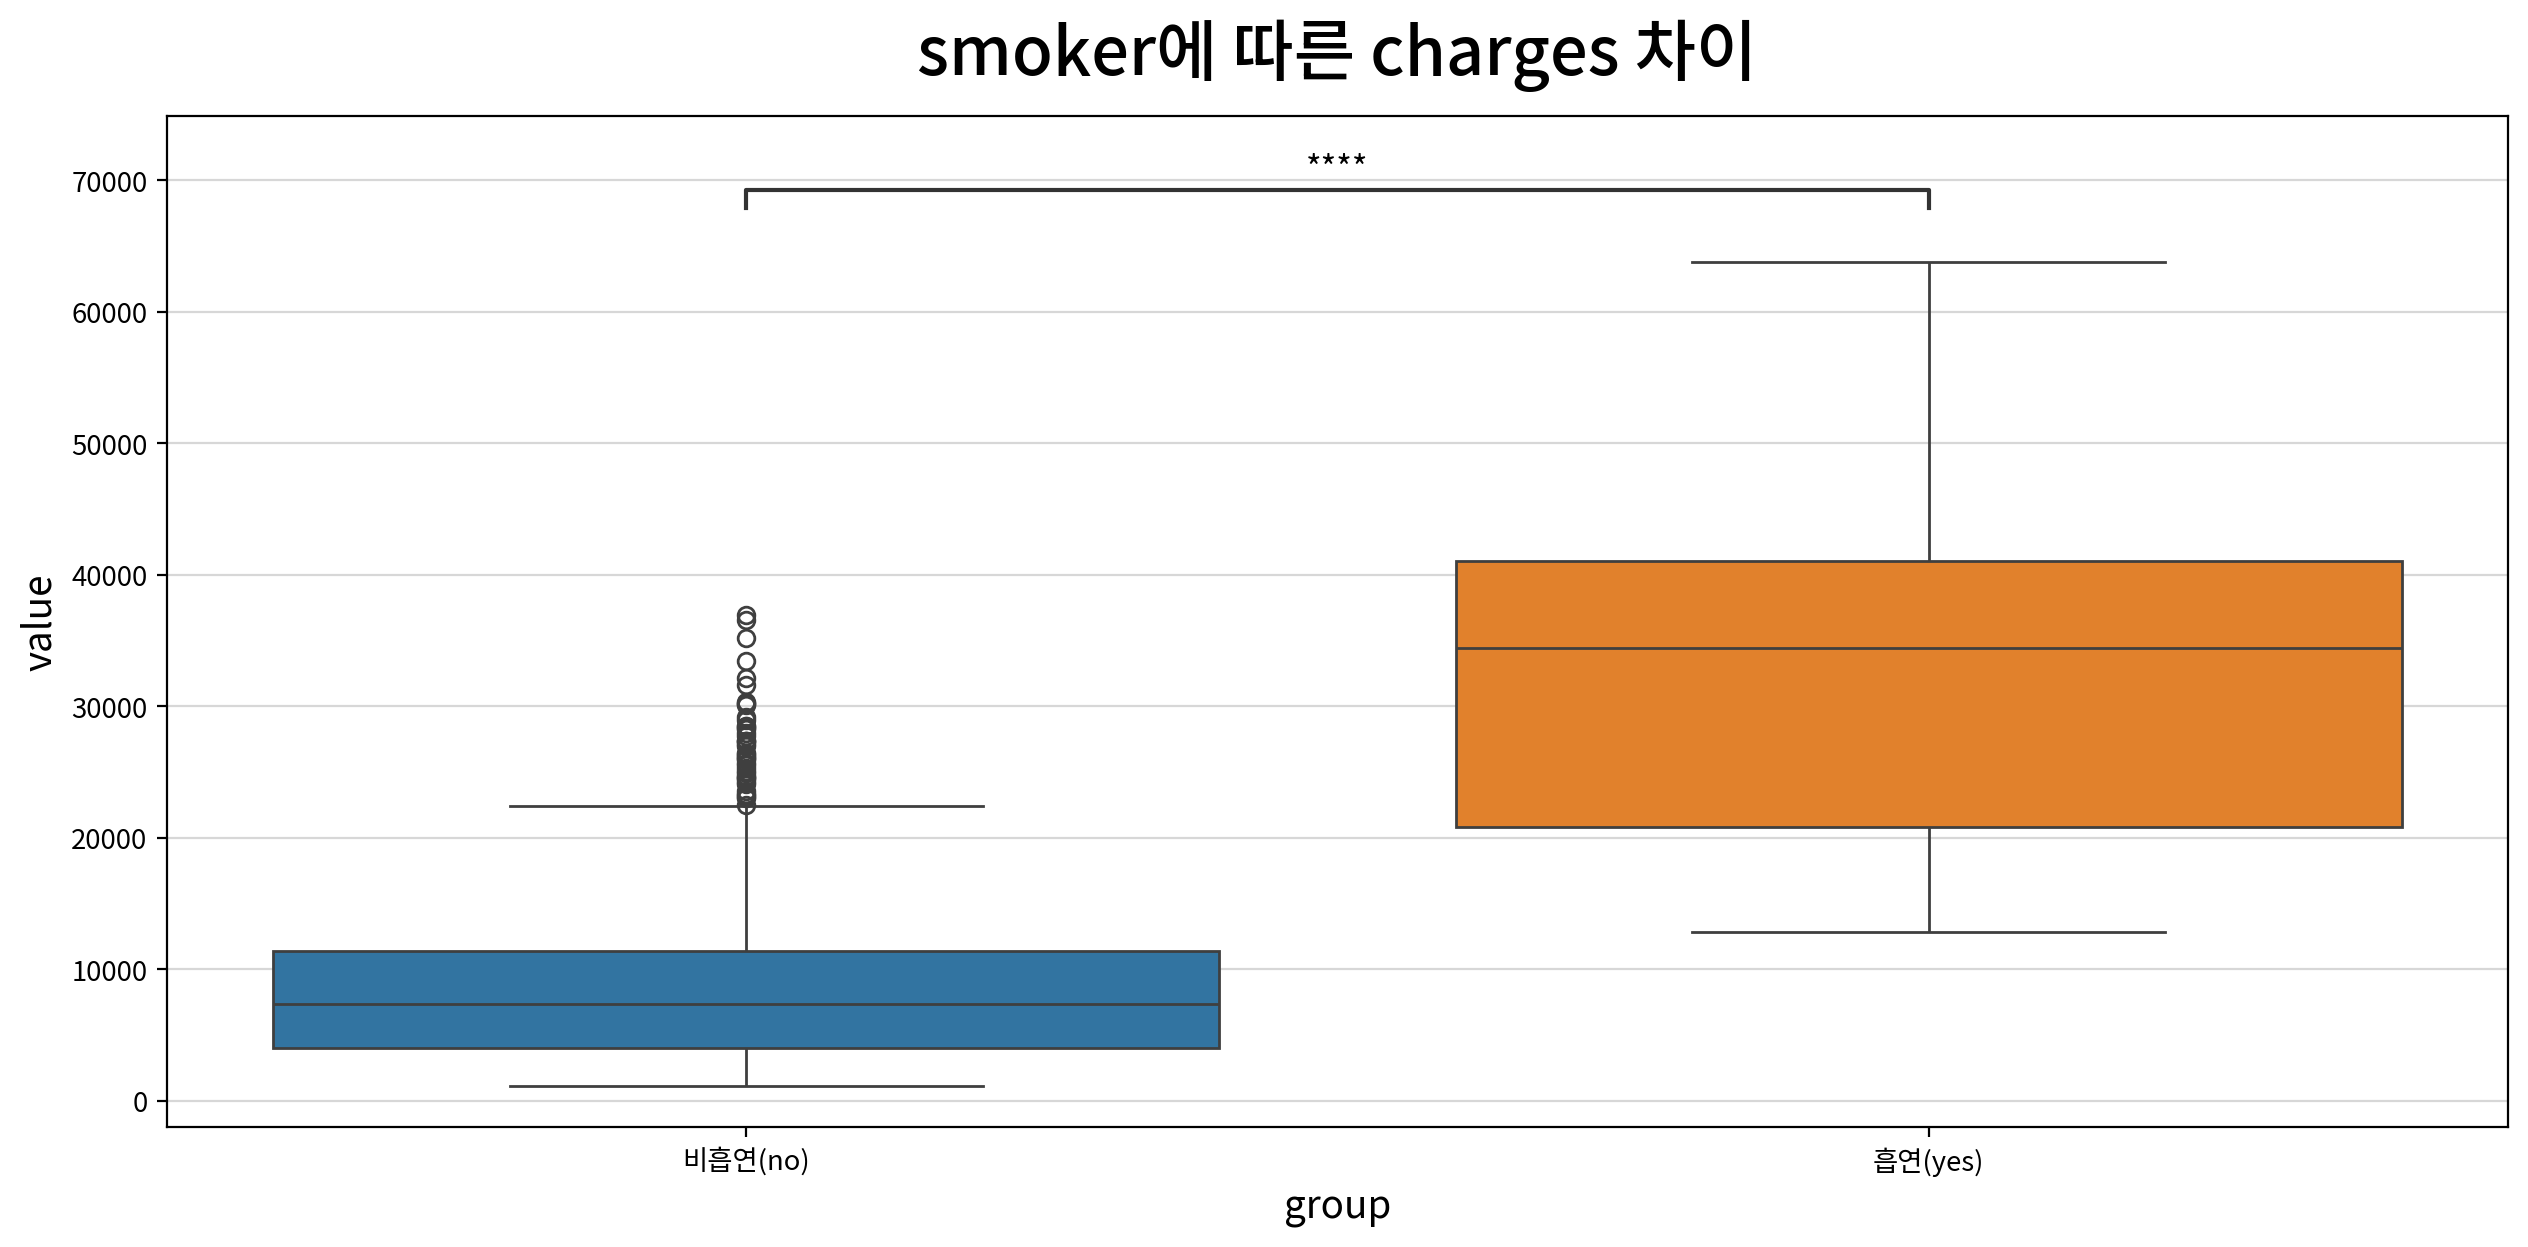

statistic  p-value  significant  \
test                alternative                                    
Mann-Whitney U test two-sided     7403.000    0.000         True   
                    less          7403.000    0.000         True   
                    greater       7403.000    1.000        False   

                                            result  
test                alternative                     
Mann-Whitney U test two-sided    비흡연(no) ≠ 흡연(yes)  
                    less         비흡연(no) < 흡연(yes)  
                    greater      비흡연(no) ≤ 흡연(yes)

In [10]:
smoker_charges = DataFrame({
    "비흡연(no)": df.loc[df["smoker"] == "no", target].reset_index(drop=True),
    "흡연(yes)": df.loc[df["smoker"] == "yes", target].reset_index(drop=True)
})

my_stats.test_independent(smoker_charges,"비흡연(no)","흡연(yes)",title="smoker에 따른 charges 차이")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

여성(female) vs. 남성(male): Mann-Whitney-Wilcoxon test two-sided, P_val:6.945e-01 U_stat=2.207e+05


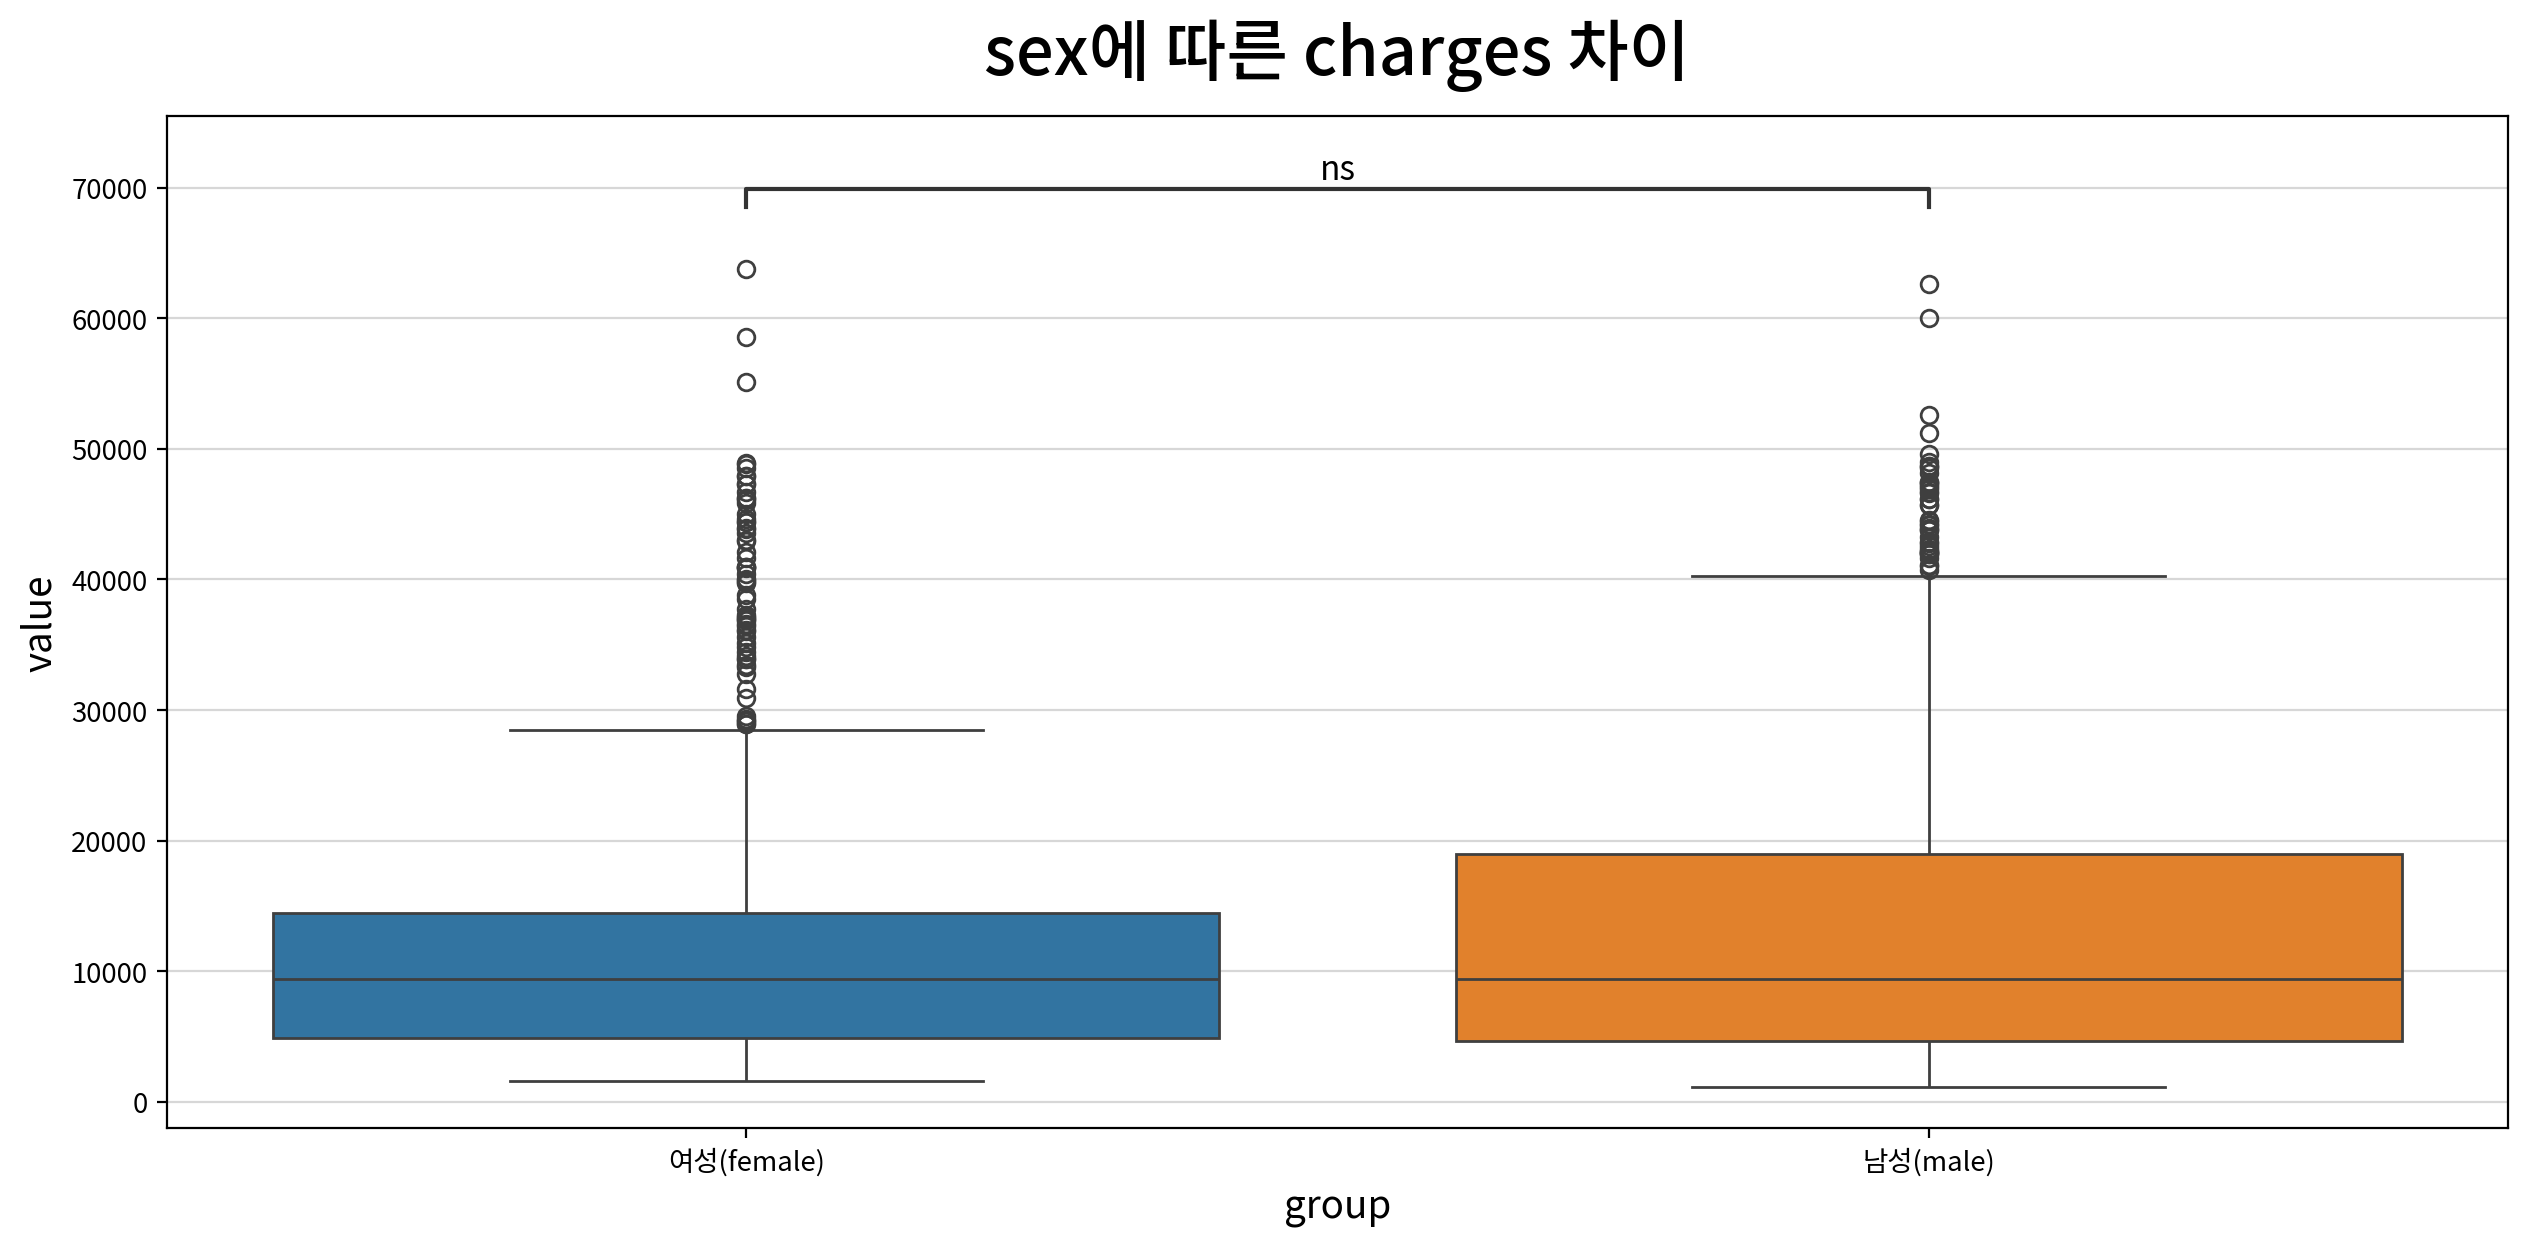

statistic  p-value  significant  \
test                alternative                                    
Mann-Whitney U test two-sided   220652.000    0.695        False   
                    less        220652.000    0.347        False   
                    greater     220652.000    0.653        False   

                                                result  
test                alternative                         
Mann-Whitney U test two-sided    여성(female) = 남성(male)  
                    less         여성(female) ≥ 남성(male)  
                    greater      여성(female) ≤ 남성(male)

In [9]:
sex_charges = DataFrame({
    "여성(female)": df.loc[df["sex"] == "female", target].reset_index(drop=True),
    "남성(male)": df.loc[df["sex"] == "male", target].reset_index(drop=True)
})

my_stats.test_independent(sex_charges, "여성(female)", "남성(male)", title="sex에 따른 charges 차이")

- 인사이트
- 명목(2) X 연속 → 두 변수 모두 T검정 계열, 정규성 위배 →Mann-Whitney U(비모수) 자동 적용

|항목|smoker|sex|
|-|-|-|
|검정|Mann-Whitney U(비모수)|Mann-Whitney U(비모수)|
|U 통계량|7403|220652|
|p-value|<0.001(유의)|0.695|
|방향(단측)|비흡연(no) < 흡연(yes), p<0.001|p>=0.05|
|결론|흡연자(smoker=yes)의 charges가 더 높다|성별에 따른 charges 차이가 없다|

- 해석 : 흡연 여부에 따라 보험료가 통계적으로 유의하게 다르며, 흡연자의 보험료가 더 비쌈
- p<0.05 유의, → smoker를 독립변수 후보로 채택
- 비모수 검정이라 Cohen's d가 출력되지 않음 → 실질 크기는 박스플롯의 중앙값 차이로 보완판단

## ANOVA
### 일원분산분석

In [11]:
my_stats.anova_oneway(df, y='charges', between='region')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,region,3,740.416,2.566,0.053,0.007,Negligible


- 인사이트
- 명목(3+) x 연속 → ANOVA. 등분산 위배 → Welch_anova 자동적용

|항목|결과|
|-|-|
|검정|Welch_anova(등분산 위배)|
|F|2.566|
|p-value|>=0.053 → 유의하지 않음|
|효과크기(np2)|0.007 → Negligible|

- 해석 : 지역에 따라 charges가 통계적으로 유의하게 다르지 않음